# Orbital Transfer Visualization and Mission Optimization

This notebook builds the project in layers, starting from the basic physics of orbital transfer and gradually moving toward mission-level decision making. The early layers focus on computing and visualizing transfer orbits, while the later layers compare different strategies under constraints such as transfer time, propulsion efficiency, power availability, and propellant mass.

Layout:

**Layer 1: Hohmann transfer baseline**  
   Compute and visualize a basic two-burn transfer between circular orbits.  
**Layer 2: Parameter space and tradeoff view**  
   Sweep orbit radii to understand how total `Δv` and transfer time change.  
**Layer 3: Alternative transfer strategies**  
   Compare Hohmann, bi-elliptic, and low-thrust spiral transfers.  
**Layer 4: Mini mission optimization**  
   Use a Mars satellite mission to choose the lowest-propellant feasible strategy.

The long-term goal is to turn these ideas into an interactive visualization tool where mission parameters, propulsion models, and constraints can be adjusted directly.


## Layer 1: Hohmann Transfer Baseline

Layer 1 introduces the core orbital-transfer calculation used throughout the rest of the notebook. The input is a starting circular orbit radius `r1`, a target circular orbit radius `r2`, and the central body's gravitational parameter `mu`. From these, the code computes the Hohmann transfer ellipse, the two required burns, and the transfer time.

Main outputs:

- transfer geometry: initial orbit, target orbit, and transfer ellipse
- velocity terms: circular speeds and transfer-orbit speeds
- burn costs: `Δv1`, `Δv2`, and `Δv_total`
- transfer duration: half of the transfer ellipse period

In this first layer, total `Δv` is used as the main proxy for fuel cost because rockets spend propellant to change velocity.  
N.B. `Δv` is not literally propellant mass. It is a trajectory requirement. To estimate propellant mass, the notebook later combines `Δv` with the rocket equation and an assumed engine specific impulse.


In [ ]:
import numpy as np

# Physics
MU_BODIES = {
    "Earth": 3.986e14, #(m^3/s^3)
    "Mars": 4.282e13,
    "Moon": 4.9028e12,
}


def hohmann_delta_v(r1: float, r2: float, mu: float) -> dict:
    """Return Hohmann transfer geometry, speeds, burns, and transfer time."""
    if r2 <= r1:
        raise ValueError("r2 must be greater than r1")

    # Hohmann transfer ellipse tangent to both circular orbits:
    # periapsis = r1, apoapsis = r2, so a = (r1 + r2) / 2.
    a = (r1 + r2) / 2

    # Eccentricity from periapsis/apoapsis relation:
    # e = (ra - rp) / (ra + rp).
    e = (r2 - r1) / (r2 + r1)

    # Circular speed for a circular orbit: v_c = sqrt(mu / r).
    vc1 = np.sqrt(mu / r1)
    vc2 = np.sqrt(mu / r2)

    # Transfer-orbit speed from the vis-viva equation:
    # v = sqrt(mu * (2 / r - 1 / a)).
    vt1 = np.sqrt(mu * (2 / r1 - 1 / a))
    vt2 = np.sqrt(mu * (2 / r2 - 1 / a))

    # Burn 1 enters the transfer ellipse; burn 2 circularizes at r2.
    dv1 = vt1 - vc1
    dv2 = vc2 - vt2

    # The spacecraft travels half of the transfer ellipse:
    # t = pi * sqrt(a^3 / mu).
    transfer_time = np.pi * np.sqrt(a**3 / mu)

    return {
        "r1": r1, #initial orbit radius
        "r2": r2, #target orbit radius
        "mu": mu, #gravitaty parameter of central body, mu=GM
        "a": a, #semi-major axis of transfer ellipse
        "e": e, #eccentricity of transfer ellipse
        "vc1": vc1, #circular speed at initial orbit
        "vc2": vc2, #circular speed at target orbit
        "vt1": vt1, #transfer speed at start of ellipse
        "vt2": vt2, #transfer speed at end of ellipse
        "dv1": dv1, #first burn (change in speed) needed to enter transfer orbit
        "dv2": dv2, #second burn (change in speed) needed to circularize
        "dv_total": dv1 + dv2,
        "transfer_time_s": transfer_time,
        "transfer_time_h": transfer_time / 3600,
    }


In [ ]:
import matplotlib.pyplot as plt

# Plotting
PLOT_COLORS = {
    "inner": "#3B82F6",
    "outer": "#10B981",
    "transfer": "#F97316",
    "body": "#FACC15",
}


def orbit_points(radius, scale=1e3, samples=500):
    theta = np.linspace(0, 2 * np.pi, samples)
    radius = radius / scale
    return radius * np.cos(theta), radius * np.sin(theta)


def transfer_points(result, scale=1e3, samples=500, visible_half=True):
    # Ellipse geometry:
    # b = a * sqrt(1 - e^2), and the central body sits at one focus.
    theta = np.linspace(0, np.pi, samples)
    if not visible_half:
        theta = theta + np.pi

    a = result["a"]
    b = a * np.sqrt(1 - result["e"] ** 2)

    # Place periapsis at (+r1, 0), apoapsis at (-r2, 0).
    # That puts the ellipse center at x = r1 - a.
    center_x = result["r1"] - a

    x = (center_x + a * np.cos(theta)) / scale
    y = b * np.sin(theta) / scale
    return x, y


def plot_hohmann(result: dict, unit_label: str = "km", unit_scale: float = 1e3):
    """Plot the Hohmann transfer geometry and delta-v budget."""
    fig, (ax_orbit, ax_dv) = plt.subplots(1, 2, figsize=(12, 5))
    fig.suptitle("Hohmann Transfer", fontsize=14, fontweight="bold")

    _plot_orbit_panel(ax_orbit, result, unit_label, unit_scale)
    _plot_delta_v_panel(ax_dv, result)

    fig.tight_layout()
    plt.show()


def _plot_orbit_panel(ax, result, unit_label, unit_scale):
    r1 = result["r1"]
    r2 = result["r2"]

    ax.plot(*orbit_points(r1, unit_scale), color=PLOT_COLORS["inner"], label="Inner orbit")
    ax.plot(*orbit_points(r2, unit_scale), color=PLOT_COLORS["outer"], label="Outer orbit")
    ax.plot(*transfer_points(result, unit_scale), color=PLOT_COLORS["transfer"], lw=2.5, label="Transfer")
    ax.plot(*transfer_points(result, unit_scale, visible_half=False), color=PLOT_COLORS["transfer"], ls="--", alpha=0.25)

    burn_points = [
        (r1 / unit_scale, 0, f"dv1 = {result['dv1'] / 1000:.3f} km/s", "left"),
        (-r2 / unit_scale, 0, f"dv2 = {result['dv2'] / 1000:.3f} km/s", "right"),
    ]
    for x, y, label, ha in burn_points:
        ax.scatter(x, y, s=55, color=PLOT_COLORS["transfer"], edgecolor="white", zorder=3)
        ax.annotate(label, (x, y), xytext=(8 if ha == "left" else -8, 12),
                    textcoords="offset points", ha=ha, color=PLOT_COLORS["transfer"])

    ax.scatter(0, 0, s=90, color=PLOT_COLORS["body"], edgecolor="black", zorder=4)
    limit = r2 / unit_scale * 1.15
    ax.set(xlim=(-limit, limit), ylim=(-limit, limit),
           xlabel=f"Distance ({unit_label})", ylabel=f"Distance ({unit_label})",
           title="Orbit geometry")
    ax.set_aspect("equal", adjustable="box")
    ax.grid(alpha=0.25)
    ax.legend(loc="lower right")


def _plot_delta_v_panel(ax, result):
    labels = ["dv1", "dv2", "total"]
    values = np.array([result["dv1"], result["dv2"], result["dv_total"]]) / 1000
    colors = [PLOT_COLORS["inner"], PLOT_COLORS["outer"], PLOT_COLORS["transfer"]]

    bars = ax.bar(labels, values, color=colors)
    ax.set(title="Delta-v budget", ylabel="Delta-v (km/s)")
    ax.grid(axis="y", alpha=0.25)
    ax.bar_label(bars, labels=[f"{value:.3f}" for value in values], padding=3)

    summary = (
        f"a = {result['a'] / 1e3:,.1f} km\n"
        f"e = {result['e']:.4f}\n"
        f"time = {result['transfer_time_h']:.2f} h"
    )
    ax.text(0.98, 0.95, summary, transform=ax.transAxes,
            ha="right", va="top", fontsize=9,
            bbox={"boxstyle": "round,pad=0.4", "facecolor": "white", "alpha": 0.9})


HOHMANN TRANSFER RESULTS
--------------------------------
Inner orbit r1         6,771.0 km
Outer orbit r2         42,164.0 km
Semi-major axis a      24,467.5 km
Eccentricity e         0.723266
Circular speed at r1   7.6726 km/s
Circular speed at r2   3.0747 km/s
Transfer speed at r1   10.0721 km/s
Transfer speed at r2   1.6174 km/s
Burn 1 dv1             2.3995 km/s
Burn 2 dv2             1.4572 km/s
Total dv               3.8567 km/s
Transfer time          5.29 h


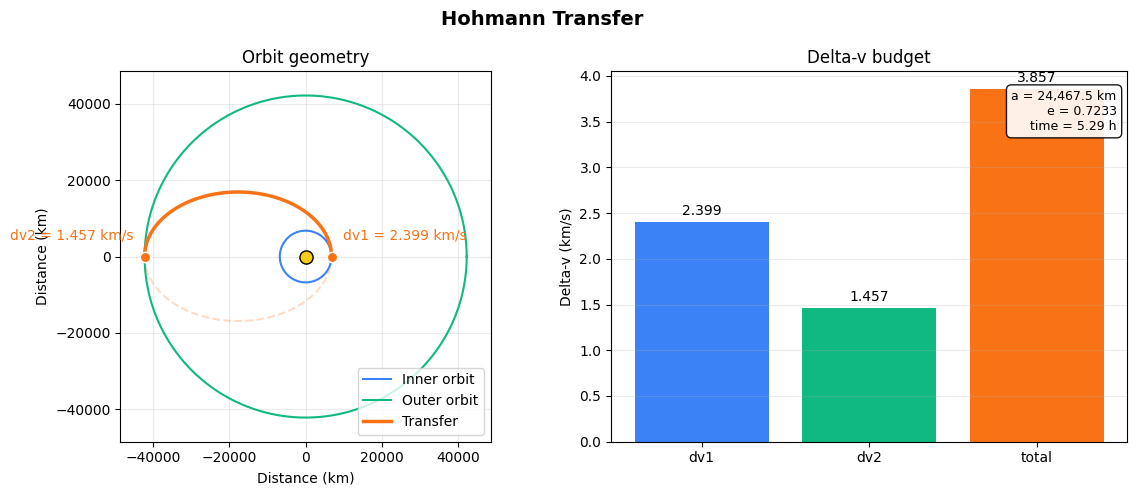

In [ ]:
# Results
def print_results(result: dict, unit_label: str = "km", unit_scale: float = 1e3):
    distance = lambda value: value / unit_scale
    speed = lambda value: value / 1000

    rows = [
        ("Inner orbit r1", f"{distance(result['r1']):,.1f} {unit_label}"),
        ("Outer orbit r2", f"{distance(result['r2']):,.1f} {unit_label}"),
        ("Semi-major axis a", f"{distance(result['a']):,.1f} {unit_label}"),
        ("Eccentricity e", f"{result['e']:.6f}"),
        ("Circular speed at r1", f"{speed(result['vc1']):.4f} km/s"),
        ("Circular speed at r2", f"{speed(result['vc2']):.4f} km/s"),
        ("Transfer speed at r1", f"{speed(result['vt1']):.4f} km/s"),
        ("Transfer speed at r2", f"{speed(result['vt2']):.4f} km/s"),
        ("Burn 1 dv1", f"{speed(result['dv1']):.4f} km/s"),
        ("Burn 2 dv2", f"{speed(result['dv2']):.4f} km/s"),
        ("Total dv", f"{speed(result['dv_total']):.4f} km/s"),
        ("Transfer time", f"{result['transfer_time_h']:.2f} h"),
    ]

    print("HOHMANN TRANSFER RESULTS")
    print("-" * 32)
    for label, value in rows:
        print(f"{label:<22} {value}")


BODY = "Earth"
R1_KM = 6_771
R2_KM = 42_164

mu = MU_BODIES[BODY]
results = hohmann_delta_v(R1_KM * 1e3, R2_KM * 1e3, mu)

print_results(results)
plot_hohmann(results)


## Layer 2: Parameter Space + Tradeoff View

Goal:

- Fix the starting orbit radius `r1`, vary the target orbit radius `r2`, and plot how `dv1`, `dv2`, `dv_total`, and transfer time change with the ratio `r2/r1`. (Using `r2/r1` makes the sweep easier to interpret than raw radii because the shape of the Hohmann equations is strongly controlled by the radius ratio.)
- Build a 2D design map with `r1` on the x-axis, `r2` on the y-axis, and color showing total delta-v. (The invalid region `r2 <= r1` is masked here because this layer only studies outward transfers.)
- Add a Pareto-style tradeoff plot between transfer time and total delta-v instead of forcing them into one artificial score.

Planned outputs:

1. Radius-ratio sweep: `r2/r1` vs delta-v components and transfer time.
2. Heatmap: total delta-v across pairs of circular orbits.
3. Pareto frontier: transfer time vs total delta-v, colored by `r2/r1`.


In [ ]:
# Layer 2.1: sweep the target orbit radius.
def sweep_target_radius(r1: float, ratios, mu: float) -> dict:
    """Evaluate Hohmann transfer over a list of target-radius ratios r2/r1."""
    ratios = np.asarray(ratios, dtype=float)
    rows = []

    for ratio in ratios:
        # This layer only studies outward transfers, so ratios must be > 1.
        if ratio <= 1:
            rows.append((np.nan, np.nan, np.nan, np.nan, np.nan))
            continue

        result = hohmann_delta_v(r1, r1 * ratio, mu)
        rows.append((
            result["dv1"],
            result["dv2"],
            result["dv_total"],
            result["transfer_time_h"],
            result["vc1"],
        ))

    data = np.array(rows)
    return {
        "r1": r1,
        "ratios": ratios,
        "r2": r1 * ratios,
        "dv1_km_s": data[:, 0] / 1000,
        "dv2_km_s": data[:, 1] / 1000,
        "dv_total_km_s": data[:, 2] / 1000,
        "transfer_time_h": data[:, 3],
        "normalized_dv": data[:, 2] / data[:, 4],
    }


def plot_radius_sweep(sweep: dict):
    """Plot delta-v components and transfer time against the radius ratio."""
    fig, ax_dv = plt.subplots(figsize=(9, 5))

    ax_dv.plot(sweep["ratios"], sweep["dv1_km_s"], label="dv1", color=PLOT_COLORS["inner"])
    ax_dv.plot(sweep["ratios"], sweep["dv2_km_s"], label="dv2", color=PLOT_COLORS["outer"])
    ax_dv.plot(sweep["ratios"], sweep["dv_total_km_s"], label="total dv",
               color=PLOT_COLORS["transfer"], lw=2.5)
    ax_dv.set(xlabel="Target radius ratio r2/r1", ylabel="Delta-v (km/s)",
              title="Hohmann transfer cost vs target orbit")
    ax_dv.grid(alpha=0.25)

    # Transfer time has a different unit, so it gets a secondary y-axis.
    ax_time = ax_dv.twinx()
    ax_time.plot(sweep["ratios"], sweep["transfer_time_h"], color="#6B7280",
                 ls="--", label="transfer time")
    ax_time.set_ylabel("Transfer time (hours)")

    lines = ax_dv.get_lines() + ax_time.get_lines()
    labels = [line.get_label() for line in lines]
    ax_dv.legend(lines, labels, loc="upper left")
    fig.tight_layout()
    plt.show()


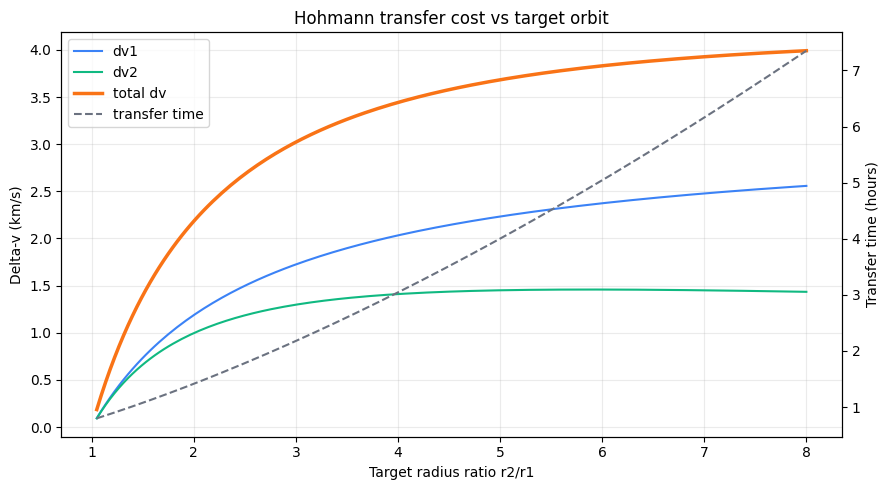

In [ ]:
ratios = np.linspace(1.05, 8.0, 160)
radius_sweep = sweep_target_radius(R1_KM * 1e3, ratios, MU_BODIES[BODY])

plot_radius_sweep(radius_sweep)


In the graph we can see that the fuel needed (approximated by speed change) for the first burn grow slowly, that's because it scales based on the square roots of the radius ratio. Meanwhile the fuel needed for the second burn actually peaks around the ratio R=3.23, and then decline and approach 0 as R increases to infinity.

In [ ]:
# Layer 2.2: map the two-radius design space.
def transfer_grid(r1_values_km, r2_values_km, mu: float) -> dict:
    """Build a grid of total delta-v and transfer time values."""
    r1_values_km = np.asarray(r1_values_km, dtype=float)
    r2_values_km = np.asarray(r2_values_km, dtype=float)

    total_dv = np.full((len(r2_values_km), len(r1_values_km)), np.nan)
    transfer_time = np.full_like(total_dv, np.nan)

    for j, r2_km in enumerate(r2_values_km):
        for i, r1_km in enumerate(r1_values_km):
            # Mask the invalid / unsupported region for outward Hohmann transfers.
            if r2_km <= r1_km:
                continue

            result = hohmann_delta_v(r1_km * 1e3, r2_km * 1e3, mu)
            total_dv[j, i] = result["dv_total"] / 1000
            transfer_time[j, i] = result["transfer_time_h"]

    return {
        "r1_values_km": r1_values_km,
        "r2_values_km": r2_values_km,
        "total_dv_km_s": total_dv,
        "transfer_time_h": transfer_time,
    }


def plot_delta_v_heatmap(grid: dict):
    """Plot a heatmap and contours for total delta-v over the radius grid."""
    r1_grid, r2_grid = np.meshgrid(grid["r1_values_km"], grid["r2_values_km"])
    total_dv = grid["total_dv_km_s"]

    fig, ax = plt.subplots(figsize=(8, 6))
    mesh = ax.pcolormesh(r1_grid, r2_grid, total_dv, shading="auto", cmap="viridis")
    contours = ax.contour(r1_grid, r2_grid, total_dv, colors="white", linewidths=0.7, alpha=0.65)
    ax.clabel(contours, fmt="%.1f", fontsize=8)

    ax.set(xlabel="Starting orbit radius r1 (km)",
           ylabel="Target orbit radius r2 (km)",
           title="Total delta-v heatmap")
    fig.colorbar(mesh, ax=ax, label="Total delta-v (km/s)")
    fig.tight_layout()
    plt.show()


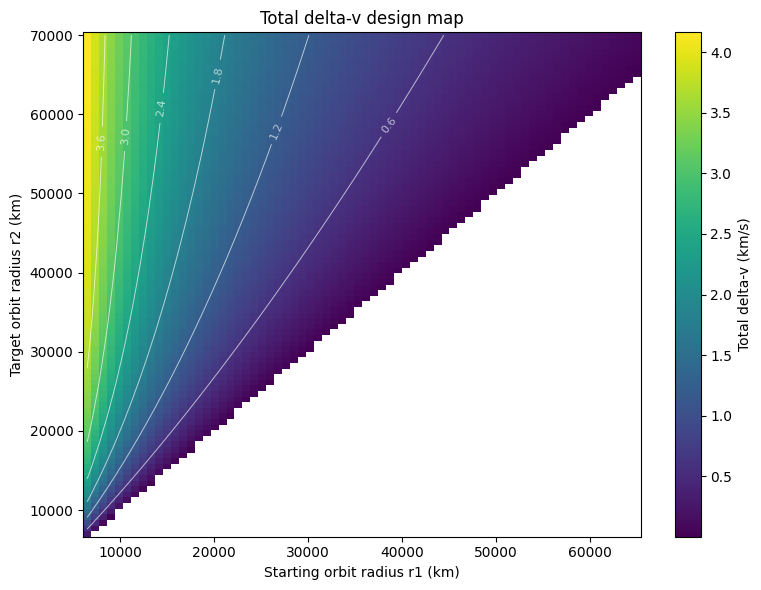

In [ ]:
r1_values_km = np.linspace(6500, 65000, 70)
r2_values_km = np.linspace(7000, 70000, 90)

dv_grid = transfer_grid(r1_values_km, r2_values_km, MU_BODIES[BODY])
plot_delta_v_heatmap(dv_grid)


In [ ]:
# Layer 2.3: Pareto frontier of transfer-time / delta-v tradeoff.
def pareto_front_indices(x_values, y_values):
    """Return indices on the lower-left Pareto front.

    Here lower is better for both axes:
    - x = transfer time
    - y = total delta-v

    A point is kept if no earlier/faster point has an equal or lower delta-v.
    """
    x_values = np.asarray(x_values, dtype=float)
    y_values = np.asarray(y_values, dtype=float)

    valid = np.isfinite(x_values) & np.isfinite(y_values)
    valid_indices = np.flatnonzero(valid)
    sorted_indices = valid_indices[np.argsort(x_values[valid])]

    front = []
    best_y = np.inf
    for index in sorted_indices:
        if y_values[index] < best_y:
            front.append(index)
            best_y = y_values[index]

    return np.array(front, dtype=int)


def transfer_tradeoff(sweep: dict) -> dict:
    """Prepare transfer-time and delta-v data for a Pareto/tradeoff plot."""
    front_indices = pareto_front_indices(
        sweep["transfer_time_h"],
        sweep["dv_total_km_s"],
    )

    return {
        "ratios": sweep["ratios"],
        "transfer_time_h": sweep["transfer_time_h"],
        "dv_total_km_s": sweep["dv_total_km_s"],
        "front_indices": front_indices,
    }


def plot_transfer_tradeoff(tradeoff: dict):
    """Plot transfer time against total delta-v, highlighting the Pareto front."""
    fig, ax = plt.subplots(figsize=(8, 5))

    scatter = ax.scatter(
        tradeoff["transfer_time_h"],
        tradeoff["dv_total_km_s"],
        c=tradeoff["ratios"],
        cmap="plasma",
        s=36,
        alpha=0.85,
    )

    front = tradeoff["front_indices"]
    ax.plot(
        tradeoff["transfer_time_h"][front],
        tradeoff["dv_total_km_s"][front],
        color="black",
        lw=1.8,
        label="Pareto front",
    )
    ax.scatter(
        tradeoff["transfer_time_h"][front],
        tradeoff["dv_total_km_s"][front],
        color="black",
        s=70,
        marker="x",
        zorder=4,
    )

    ax.set(
        xlabel="Transfer time (hours)",
        ylabel="Total delta-v (km/s)",
        title="Transfer time vs total delta-v",
    )
    ax.grid(alpha=0.25)
    ax.legend(loc="best")
    fig.colorbar(scatter, ax=ax, label="Target radius ratio r2/r1")
    fig.tight_layout()
    plt.show()


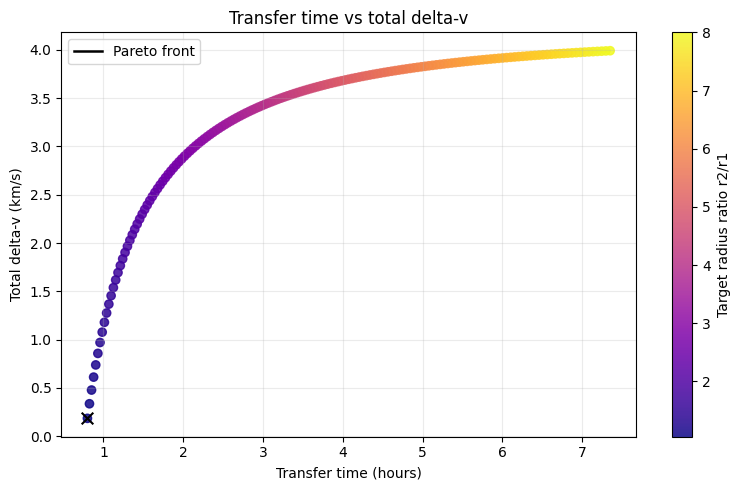

In [ ]:
transfer_pareto = transfer_tradeoff(radius_sweep)
plot_transfer_tradeoff(transfer_pareto)


The Pareto frontier shows how total Δv and transfer time move together, while the target orbit ratio increases. For this specific fixed-`r1` Hohmann sweep, the Pareto front may collapse to the smallest radius ratio because larger target orbits usually require both more time and more total Δv. However, in a real mission, the target orbit is usually constrained by the mission objective. Optimization then compares feasible strategies for that target, or evaluates a benefit metric such as constellation coverage, payload delivered, revisit time, or science return.
A Pareto frontier becomes more meaningful when comparing different transfer strategies for the same `r1 -> r2`, or when adding another axis for the benefit metric, which will be shown in the following layers.


## Layer 3: Alternative Transfer Strategies

Goal:

Compare three transfer strategies between circular orbits:

1. **Hohmann transfer**: a two-burn transfer using one ellipse tangent to both circular orbits. It is the baseline impulsive strategy.
2. **Bi-elliptic transfer**: a three-burn transfer that raises apoapsis to an intermediate radius `rb`, switches to a second ellipse, then circularizes at the target orbit.
3. **Low-thrust spiral**: a continuous-thrust transfer that slowly raises the orbit instead of using instantaneous burns. This is a simplified model, but it gives a useful contrast against impulsive transfers.

The comparison now asks two questions:

- How much total velocity change does each strategy require?
- How much transfer time does each strategy pay for that velocity change?

This gives a more useful tradeoff picture than a single "best" score, especially because low-thrust transfers can have very different time scales.[^L3-1]

[^L3-1]: The low-thrust spiral model here uses a simple circular-spiral approximation. A real low-thrust trajectory would require numerical propagation, thrust direction control, spacecraft mass change, and operational constraints.


In [ ]:
# Layer 3.1: geometry helpers for Hohmann, bi-elliptic, and low-thrust transfers.
def ellipse_arc_points(rp, ra, theta_start, theta_end, scale=1e3, samples=500):
    """Return points on an ellipse with periapsis at (+rp, 0) and apoapsis at (-ra, 0)."""
    a = (rp + ra) / 2
    e = (ra - rp) / (ra + rp)
    b = a * np.sqrt(1 - e**2)
    center_x = rp - a

    theta = np.linspace(theta_start, theta_end, samples)
    x = (center_x + a * np.cos(theta)) / scale
    y = b * np.sin(theta) / scale
    return x, y


def spiral_points(r1, r2, revolutions=5, scale=1e3, samples=1200):
    """Return a simple outward spiral used to visualize low-thrust orbit raising."""
    theta = np.linspace(0, 2 * np.pi * revolutions, samples)
    radius = np.linspace(r1, r2, samples) / scale
    return radius * np.cos(theta), radius * np.sin(theta)


def plot_strategy_geometry(r1, r2, rb, unit_label="km", unit_scale=1e3):
    """Draw geometry examples for Hohmann, bi-elliptic, and low-thrust transfers."""
    fig, axes = plt.subplots(2, 2, figsize=(12, 10))
    axes = axes.ravel()
    fig.suptitle("Transfer Geometry: Hohmann, Bi-elliptic, and Low-thrust", fontsize=14, fontweight="bold")

    orbit_specs = [
        (r1, PLOT_COLORS["inner"], "start orbit"),
        (r2, PLOT_COLORS["outer"], "target orbit"),
    ]

    # Hohmann: one half-ellipse from r1 periapsis to r2 apoapsis.
    ax = axes[0]
    _draw_base_orbits(ax, orbit_specs, unit_scale)
    ax.plot(*ellipse_arc_points(r1, r2, 0, np.pi, unit_scale),
            color=PLOT_COLORS["transfer"], lw=2.5, label="Hohmann transfer")
    ax.scatter([0], [0], s=70, color=PLOT_COLORS["body"], edgecolor="black", zorder=4)
    _format_strategy_axis(ax, r2, unit_label, unit_scale, "Hohmann")

    # Bi-elliptic full frame: useful for showing how far rb is.
    ax = axes[1]
    _draw_bi_elliptic(ax, r1, r2, rb, orbit_specs, unit_scale, show_rb=True)
    _format_strategy_axis(ax, rb, unit_label, unit_scale, "Bi-elliptic full frame")

    # Bi-elliptic inner zoom: useful for seeing the start and target orbits.
    ax = axes[2]
    _draw_bi_elliptic(ax, r1, r2, rb, orbit_specs, unit_scale, show_rb=False)
    _format_strategy_axis(ax, r2 * 1.25, unit_label, unit_scale, "Bi-elliptic inner zoom")

    # Low-thrust spiral: a visual approximation of continuous outward orbit raising.
    ax = axes[3]
    _draw_base_orbits(ax, orbit_specs, unit_scale)
    ax.plot(*spiral_points(r1, r2, revolutions=5, scale=unit_scale),
            color="#0EA5E9", lw=2.3, label="low-thrust spiral")
    ax.scatter([0], [0], s=70, color=PLOT_COLORS["body"], edgecolor="black", zorder=4)
    _format_strategy_axis(ax, r2 * 1.25, unit_label, unit_scale, "Low-thrust spiral")

    for ax in axes:
        ax.legend(loc="lower right", fontsize=8)
    fig.tight_layout()
    plt.show()


def _draw_base_orbits(ax, orbit_specs, unit_scale):
    for radius, color, label in orbit_specs:
        ax.plot(*orbit_points(radius, unit_scale), color=color, alpha=0.9, lw=2.0, label=label)


def _draw_bi_elliptic(ax, r1, r2, rb, orbit_specs, unit_scale, show_rb):
    _draw_base_orbits(ax, orbit_specs, unit_scale)
    if show_rb:
        ax.plot(*orbit_points(rb, unit_scale), color="#9CA3AF", alpha=0.35, ls="--", label="intermediate rb")
    ax.plot(*ellipse_arc_points(r1, rb, 0, np.pi, unit_scale),
            color=PLOT_COLORS["transfer"], lw=2.4, label="leg 1")
    ax.plot(*ellipse_arc_points(r2, rb, np.pi, 2 * np.pi, unit_scale),
            color="#8B5CF6", lw=2.4, label="leg 2")
    ax.scatter([0], [0], s=70, color=PLOT_COLORS["body"], edgecolor="black", zorder=4)


def _format_strategy_axis(ax, outer_radius, unit_label, unit_scale, title):
    limit = outer_radius / unit_scale * 1.12
    ax.set(xlim=(-limit, limit), ylim=(-limit, limit),
           xlabel=f"Distance ({unit_label})", ylabel=f"Distance ({unit_label})",
           title=title)
    ax.set_aspect("equal", adjustable="box")
    ax.grid(alpha=0.25)


In [ ]:
# Layer 3.2: transfer models.
def bi_elliptic_transfer(r1: float, r2: float, rb: float, mu: float) -> dict:
    """Return delta-v and time for an outward bi-elliptic transfer."""
    if not (r1 < r2 <= rb):
        raise ValueError("Require r1 < r2 <= rb for this outward bi-elliptic model.")

    if np.isclose(rb, r2):
        baseline = hohmann_delta_v(r1, r2, mu)
        return {
            "strategy": "Bi-elliptic",
            "r1": r1,
            "r2": r2,
            "rb": rb,
            "dv1": baseline["dv1"],
            "dv2": baseline["dv2"],
            "dv3": 0.0,
            "dv_total": baseline["dv_total"],
            "transfer_time_h": baseline["transfer_time_h"],
        }

    vc1 = np.sqrt(mu / r1)
    vc2 = np.sqrt(mu / r2)

    # First transfer ellipse: periapsis r1, apoapsis rb.
    a1 = (r1 + rb) / 2
    v1_peri = np.sqrt(mu * (2 / r1 - 1 / a1))
    v1_apo = np.sqrt(mu * (2 / rb - 1 / a1))

    # Second transfer ellipse: apoapsis rb, periapsis r2.
    a2 = (r2 + rb) / 2
    v2_apo = np.sqrt(mu * (2 / rb - 1 / a2))
    v2_peri = np.sqrt(mu * (2 / r2 - 1 / a2))

    dv1 = v1_peri - vc1
    dv2 = abs(v2_apo - v1_apo)
    dv3 = abs(v2_peri - vc2)

    transfer_time = np.pi * np.sqrt(a1**3 / mu) + np.pi * np.sqrt(a2**3 / mu)

    return {
        "strategy": "Bi-elliptic",
        "r1": r1,
        "r2": r2,
        "rb": rb,
        "a1": a1,
        "a2": a2,
        "dv1": dv1,
        "dv2": dv2,
        "dv3": dv3,
        "dv_total": dv1 + dv2 + dv3,
        "transfer_time_h": transfer_time / 3600,
    }


def low_thrust_spiral_transfer(r1: float, r2: float, mu: float, acceleration: float) -> dict:
    """Approximate a coplanar circular low-thrust spiral transfer.

    The delta-v estimate is the ideal tangential spiral relation:
    dv ~= sqrt(mu / r1) - sqrt(mu / r2) for outward orbit raising.
    Transfer time is estimated from constant acceleration: t ~= dv / a.
    """
    if r2 <= r1:
        raise ValueError("Require r2 > r1 for this outward low-thrust model.")
    if acceleration <= 0:
        raise ValueError("acceleration must be positive.")

    dv_total = np.sqrt(mu / r1) - np.sqrt(mu / r2)
    transfer_time = dv_total / acceleration

    return {
        "strategy": "Low-thrust spiral",
        "r1": r1,
        "r2": r2,
        "acceleration": acceleration,
        "dv_total": dv_total,
        "transfer_time_h": transfer_time / 3600,
    }


def strategy_candidates(r1: float, r2: float, rb_ratios, mu: float) -> dict:
    """Compare one Hohmann transfer with a family of bi-elliptic transfers."""
    rb_ratios = np.asarray(rb_ratios, dtype=float)
    hohmann = hohmann_delta_v(r1, r2, mu)

    labels = ["Hohmann"]
    strategies = ["Hohmann"]
    rb_ratio_values = [np.nan]
    dv_total = [hohmann["dv_total"] / 1000]
    transfer_time = [hohmann["transfer_time_h"]]

    for ratio in rb_ratios:
        rb = r1 * ratio
        if rb < r2:
            continue
        result = bi_elliptic_transfer(r1, r2, rb, mu)
        labels.append(f"rb/r1={ratio:.1f}")
        strategies.append("Bi-elliptic")
        rb_ratio_values.append(ratio)
        dv_total.append(result["dv_total"] / 1000)
        transfer_time.append(result["transfer_time_h"])

    return {
        "labels": np.array(labels, dtype=object),
        "strategy": np.array(strategies, dtype=object),
        "rb_ratio": np.array(rb_ratio_values, dtype=float),
        "dv_total_km_s": np.array(dv_total, dtype=float),
        "transfer_time_h": np.array(transfer_time, dtype=float),
    }


In [34]:
# Layer 3.3: compare transfer families with three clear strategy curves.
def best_bi_elliptic_for_target_ratio(r1: float, target_ratio: float, rb_max_ratio: float, mu: float) -> dict:
    """Find the minimum-delta-v bi-elliptic candidate for one target ratio."""
    r2 = r1 * target_ratio

    # Include rb = r2 so the bi-elliptic family can collapse to Hohmann at the left edge.
    rb_ratios = np.geomspace(target_ratio, rb_max_ratio, 120)
    candidates = [
        bi_elliptic_transfer(r1, r2, r1 * rb_ratio, mu)
        for rb_ratio in rb_ratios
    ]
    best = min(candidates, key=lambda item: item["dv_total"])
    best["rb_ratio"] = best["rb"] / r1
    return best


def transfer_family_curves(
    r1: float,
    target_ratios,
    mu: float,
    rb_max_ratio: float = 200,
    low_thrust_acceleration: float = 2e-4,
) -> dict:
    """Build Hohmann, best-bi-elliptic, and low-thrust curves over target orbit ratios."""
    target_ratios = np.asarray(target_ratios, dtype=float)

    hohmann_dv = []
    hohmann_time = []
    bi_dv = []
    bi_time = []
    bi_rb_ratio = []
    low_dv = []
    low_time = []

    for target_ratio in target_ratios:
        r2 = r1 * target_ratio
        h = hohmann_delta_v(r1, r2, mu)
        b = best_bi_elliptic_for_target_ratio(r1, target_ratio, rb_max_ratio, mu)
        low = low_thrust_spiral_transfer(r1, r2, mu, low_thrust_acceleration)

        hohmann_dv.append(h["dv_total"] / 1000)
        hohmann_time.append(h["transfer_time_h"])
        bi_dv.append(b["dv_total"] / 1000)
        bi_time.append(b["transfer_time_h"])
        bi_rb_ratio.append(b["rb_ratio"])
        low_dv.append(low["dv_total"] / 1000)
        low_time.append(low["transfer_time_h"])

    return {
        "target_ratios": target_ratios,
        "low_thrust_acceleration": low_thrust_acceleration,
        "hohmann_dv_km_s": np.array(hohmann_dv),
        "hohmann_time_h": np.array(hohmann_time),
        "bi_dv_km_s": np.array(bi_dv),
        "bi_time_h": np.array(bi_time),
        "bi_rb_ratio": np.array(bi_rb_ratio),
        "low_dv_km_s": np.array(low_dv),
        "low_time_h": np.array(low_time),
    }


def plot_transfer_family_curves(curves: dict):
    """Plot three transfer-family curves: Hohmann, best bi-elliptic, low-thrust."""
    ratios = curves["target_ratios"]
    savings_m_s = (curves["hohmann_dv_km_s"] - curves["bi_dv_km_s"]) * 1000

    fig, (ax_dv, ax_time) = plt.subplots(1, 2, figsize=(12, 4.8))

    ax_dv.plot(ratios, curves["hohmann_dv_km_s"], color=PLOT_COLORS["transfer"],
               lw=2.5, label="Hohmann")
    ax_dv.plot(ratios, curves["bi_dv_km_s"], color="#8B5CF6",
               lw=2.5, label="Best bi-elliptic")
    ax_dv.plot(ratios, curves["low_dv_km_s"], color="#0EA5E9",
               lw=2.5, label="Low-thrust spiral")
    ax_dv.set(xlabel="Target radius ratio r2/r1",
              ylabel="Total delta-v (km/s)",
              title="Delta-v comparison")
    ax_dv.grid(alpha=0.25)
    ax_dv.legend(loc="lower right")
    ax_time.plot(ratios, curves["hohmann_time_h"] / 24, color=PLOT_COLORS["transfer"],
                 lw=2.5, label="Hohmann")
    ax_time.plot(ratios, curves["bi_time_h"] / 24, color="#8B5CF6",
                 lw=2.5, label="Best bi-elliptic")
    ax_time.plot(ratios, curves["low_time_h"] / 24, color="#0EA5E9",
                 lw=2.5, label="Low-thrust spiral")
    ax_time.set_yscale("log")
    ax_time.set(xlabel="Target radius ratio r2/r1",
                ylabel="Transfer time (days, log scale)",
                title="Time cost of the same strategies")
    ax_time.grid(alpha=0.25, which="both")
    ax_time.legend(loc="best")

    fig.tight_layout()
    plt.show()

    return savings_m_s


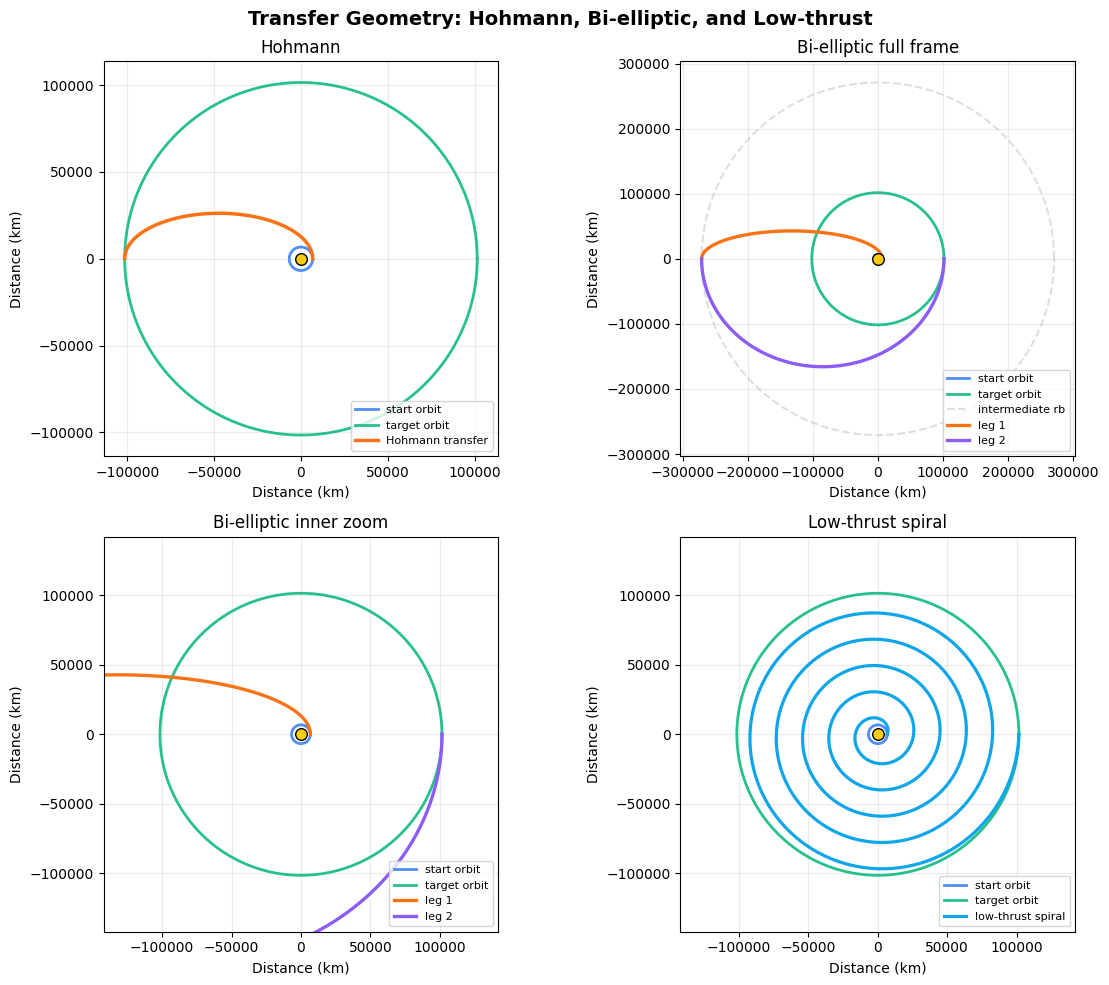

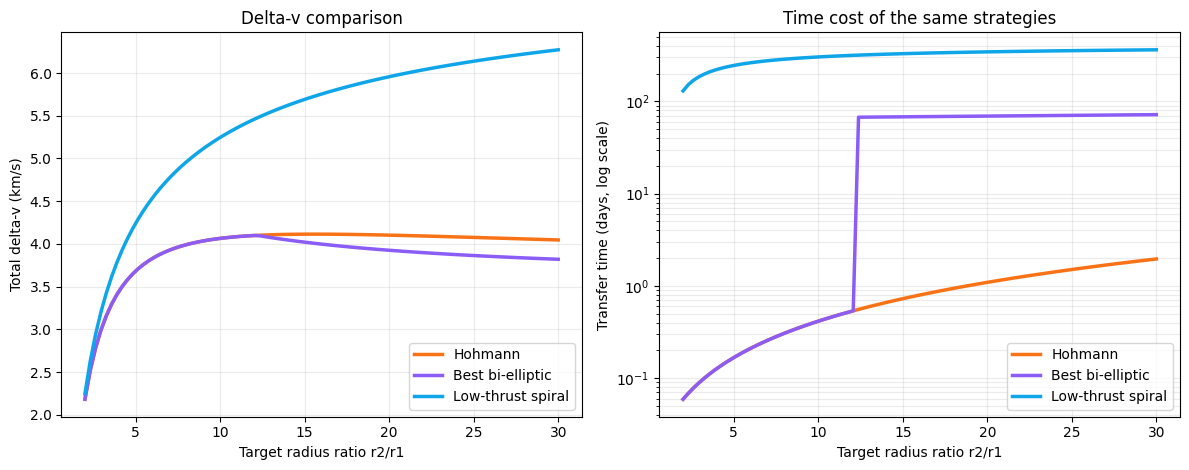

In [35]:
# Sweep target ratios so all three transfer strategies appear as readable lines.
LAYER3_BODY = globals().get("BODY", "Earth")
LAYER3_R1_KM = globals().get("R1_KM", 6_771)
LAYER3_R1 = LAYER3_R1_KM * 1e3

# Representative low-thrust acceleration: 0.2 mm/s^2.
LOW_THRUST_ACCELERATION = 2e-4

target_ratios = np.linspace(2.0, 30.0, 90)
transfer_curves = transfer_family_curves(
    LAYER3_R1,
    target_ratios,
    MU_BODIES[LAYER3_BODY],
    rb_max_ratio=200,
    low_thrust_acceleration=LOW_THRUST_ACCELERATION,
)

# Geometry example: one large-ratio case where the bi-elliptic shape is visible.
plot_strategy_geometry(
    LAYER3_R1,
    LAYER3_R1 * 15.0,
    rb=40 * LAYER3_R1,
)
layer3_savings_m_s = plot_transfer_family_curves(transfer_curves)


The comparison graphs of Δv and the time cost reveal some intersting facts. Firstly, for a small enough ratio, there is no real benefit to go out to rb so the best bi-elliptic transfer collapse into a Hohmann-like solution. After a certain threshold where the bi-elliptic optimizer chooses a very large rb it can save some energy(change in speed) but the transfer time jumps by a lot.

Secondly, Hohmann and bi-elliptic are both impulsive-burn models. Low-thrust spiral is different as it assumes continuous tangential thrust and slowly raising the orbit. In this project we used a simplified circular-spiral approximation and it is served as a simple contrast instead of a full trajectory optimization. (The low-thrust approximation uses `dv ~= sqrt(mu/r1) - sqrt(mu/r2)` for outward circular spiraling. A real model would propagate the trajectory under finite thrust and changing spacecraft mass.)

Lastly, low-thrust transfers can look worse than Hohmann and bi-elliptic under a pure Δv and time comparison, but low-thrust engines, such as electric or ion thrusters, usually produce very small acceleration but have much higher specific impulse than chemical engines, meaning they use propellant much more efficiently. Therefore, even if a low-thrust spiral requires a larger total Δv and much longer transfer time, it may still need less propellant mass than an impulsive transfer with chemical engines. A realistic comparison for a real mission should therefore include engine efficiency, specific impulse, and propellant fraction, not only Δv.

## Layer 4: Mini Mission Optimization

Mission:

A spacecraft has arrived at Mars and is captured into a low circular parking orbit. The mission is to move the satellite from low Mars orbit to a higher communication orbit while minimizing propellant mass.

Objective:

```text
minimize propellant mass
```

Given:

- Central body: Mars
- Initial orbit altitude: 300 km
- Target orbit altitude: 17,000 km
- Initial spacecraft mass: 1,000 kg
- Maximum transfer time: 30 days

Candidate strategies:

1. Hohmann transfer with chemical propulsion
2. Best feasible bi-elliptic transfer with chemical propulsion
3. Low-thrust spiral with electric propulsion

Mission constraints:

- **Operations window:** transfer time must stay below the mission time limit of 30 days. This represents the idea that a spacecraft cannot spend unlimited time in a transfer orbit before beginning its useful mission.
- **Power availability:** the low-thrust electric option must fit within the available spacecraft power. Here power is estimated from thrust, exhaust velocity, and an assumed thruster efficiency.
- **Operational risk:** each strategy gets a simple risk score from maneuver count and transfer duration. This is not a flight-safety model; it is a readable proxy for the fact that more burns and longer operations usually add complexity.

This layer uses the rocket equation to convert each strategy's total `Δv` into propellant mass. The goal is not to produce a flight-ready Mars mission design. This is a simplified mission-level optimization layer that connects trajectory choice, engine efficiency, transfer time, power availability, operational complexity, and propellant mass.


In [39]:
# Layer 4.1: mission objective, rocket-equation, and constraint helpers.
G0 = 9.80665  # standard gravity (m/s^2)
MARS_RADIUS_KM = 3_389.5


ENGINE_MODELS = {
    "chemical": {
        "isp_s": 320,
        "note": "representative storable chemical propulsion",
    },
    "electric": {
        "isp_s": 2_000,
        "acceleration_m_s2": 2e-4,
        "thruster_efficiency": 0.60,
        "note": "representative low-thrust electric propulsion",
    },
}


def propellant_mass_from_delta_v(delta_v: float, initial_mass: float, isp_s: float) -> dict:
    """Convert delta-v into propellant mass using the Tsiolkovsky rocket equation."""
    mass_ratio = np.exp(delta_v / (isp_s * G0))
    final_mass = initial_mass / mass_ratio
    propellant_mass = initial_mass - final_mass

    return {
        "mass_ratio": mass_ratio,
        "final_mass_kg": final_mass,
        "propellant_mass_kg": propellant_mass,
        "propellant_fraction": propellant_mass / initial_mass,
    }


def estimate_electric_power_kw(initial_mass_kg, acceleration_m_s2, isp_s, efficiency):
    """Estimate electric propulsion power using P ~= thrust * exhaust_velocity / (2 * efficiency)."""
    thrust_n = initial_mass_kg * acceleration_m_s2
    exhaust_velocity = isp_s * G0
    return thrust_n * exhaust_velocity / (2 * efficiency) / 1000


def operational_risk_score(burn_count, transfer_time_days, time_weight=0.05):
    """Simple risk proxy: more maneuvers and longer operations increase the score."""
    return burn_count + time_weight * transfer_time_days


def make_mission_candidate(
    name,
    transfer_result,
    engine_key,
    initial_mass_kg,
    time_limit_days,
    available_power_kw,
    risk_limit,
    burn_count,
):
    """Package one transfer result as a mission candidate with simple constraints."""
    engine = ENGINE_MODELS[engine_key]
    mass = propellant_mass_from_delta_v(
        transfer_result["dv_total"],
        initial_mass_kg,
        engine["isp_s"],
    )
    transfer_time_days = transfer_result["transfer_time_h"] / 24

    if engine_key == "electric":
        required_power_kw = estimate_electric_power_kw(
            initial_mass_kg,
            engine["acceleration_m_s2"],
            engine["isp_s"],
            engine["thruster_efficiency"],
        )
    else:
        required_power_kw = 0.0

    risk_score = operational_risk_score(burn_count, transfer_time_days)
    constraints = {
        "time_ok": transfer_time_days <= time_limit_days,
        "power_ok": required_power_kw <= available_power_kw,
        "risk_ok": risk_score <= risk_limit,
    }

    return {
        "strategy": name,
        "engine": engine_key,
        "isp_s": engine["isp_s"],
        "burn_count": burn_count,
        "delta_v_km_s": transfer_result["dv_total"] / 1000,
        "transfer_time_days": transfer_time_days,
        "propellant_mass_kg": mass["propellant_mass_kg"],
        "propellant_fraction": mass["propellant_fraction"],
        "final_mass_kg": mass["final_mass_kg"],
        "required_power_kw": required_power_kw,
        "risk_score": risk_score,
        "constraints": constraints,
        "feasible": all(constraints.values()),
    }


def best_bi_elliptic_mission_candidate(
    r1,
    r2,
    rb_max_ratio,
    mu,
    initial_mass_kg,
    time_limit_days,
    available_power_kw,
    risk_limit,
):
    """Search bi-elliptic candidates and keep the feasible one with minimum propellant."""
    target_ratio = r2 / r1
    rb_ratios = np.geomspace(target_ratio, rb_max_ratio, 160)
    candidates = []

    for rb_ratio in rb_ratios:
        transfer = bi_elliptic_transfer(r1, r2, r1 * rb_ratio, mu)
        candidate = make_mission_candidate(
            name=f"Bi-elliptic (rb/r1={rb_ratio:.1f})",
            transfer_result=transfer,
            engine_key="chemical",
            initial_mass_kg=initial_mass_kg,
            time_limit_days=time_limit_days,
            available_power_kw=available_power_kw,
            risk_limit=risk_limit,
            burn_count=3,
        )
        candidate["rb_ratio"] = rb_ratio
        candidates.append(candidate)

    feasible = [candidate for candidate in candidates if candidate["feasible"]]
    return min(feasible or candidates, key=lambda item: item["propellant_mass_kg"]), candidates


The rocket equation is needed because a spacecraft must accelerate not only its payload and structure, but also the propellant it has not burned yet, so propellant demand grows nonlinearly with required Δv. It works by relating the required velocity change to the engine exhaust speed: Δv = Isp * g0 * ln(m0 / mf), where m0 is initial mass, mf is final mass after the burn, Isp is specific impulse, and g0 = 9.80665 m/s². The key technical detail is the logarithm: each extra unit of Δv requires a larger mass ratio, so high-Isp engines reduce propellant fraction by increasing effective exhaust velocity ve = Isp * g0.

In [44]:
# Layer 4.2: Mars mini mission definition and candidate evaluation.
MISSION = {
    "body": "Mars",
    "initial_altitude_km": 300,
    "target_altitude_km": 17_000,
    "initial_mass_kg": 1_000,
    "time_limit_days": 30,
    "available_power_kw": 5,
    "risk_limit": 5,
    "rb_max_ratio": 80,
}

mars_mu = MU_BODIES[MISSION["body"]]
mars_r1 = (MARS_RADIUS_KM + MISSION["initial_altitude_km"]) * 1e3
mars_r2 = (MARS_RADIUS_KM + MISSION["target_altitude_km"]) * 1e3

hohmann_candidate = make_mission_candidate(
    "Hohmann",
    hohmann_delta_v(mars_r1, mars_r2, mars_mu),
    engine_key="chemical",
    initial_mass_kg=MISSION["initial_mass_kg"],
    time_limit_days=MISSION["time_limit_days"],
    available_power_kw=MISSION["available_power_kw"],
    risk_limit=MISSION["risk_limit"],
    burn_count=2,
)

bi_candidate, bi_search = best_bi_elliptic_mission_candidate(
    mars_r1,
    mars_r2,
    MISSION["rb_max_ratio"],
    mars_mu,
    MISSION["initial_mass_kg"],
    MISSION["time_limit_days"],
    MISSION["available_power_kw"],
    MISSION["risk_limit"],
)

low_thrust_candidate = make_mission_candidate(
    "Low-thrust spiral",
    low_thrust_spiral_transfer(
        mars_r1,
        mars_r2,
        mars_mu,
        ENGINE_MODELS["electric"]["acceleration_m_s2"],
    ),
    engine_key="electric",
    initial_mass_kg=MISSION["initial_mass_kg"],
    time_limit_days=MISSION["time_limit_days"],
    available_power_kw=MISSION["available_power_kw"],
    risk_limit=MISSION["risk_limit"],
    burn_count=1,
)

mission_candidates = [hohmann_candidate, bi_candidate, low_thrust_candidate]
feasible_candidates = [candidate for candidate in mission_candidates if candidate["feasible"]]
best_candidate = min(feasible_candidates, key=lambda item: item["propellant_mass_kg"])

print("MARS MINI MISSION")
print("-" * 104)
print(f"Initial orbit radius: {mars_r1 / 1e3:,.1f} km")
print(f"Target orbit radius:  {mars_r2 / 1e3:,.1f} km")
print(f"Initial mass:         {MISSION['initial_mass_kg']:,.0f} kg")
print(f"Time limit:           {MISSION['time_limit_days']} days")
print(f"Available power:      {MISSION['available_power_kw']} kW")
print(f"Risk limit:           {MISSION['risk_limit']}")
print("-" * 104)
print(
    f"{'strategy':<28} {'engine':<10} {'dv km/s':>9} {'time d':>9} "
    f"{'prop kg':>10} {'power kW':>10} {'risk':>7} {'constraints':>16} {'feasible':>9}"
)
for candidate in mission_candidates:
    constraint_text = "/".join(
        key.replace("_ok", "") for key, ok in candidate["constraints"].items() if not ok
    ) or "ok"
    print(
        f"{candidate['strategy']:<28} "
        f"{candidate['engine']:<10} "
        f"{candidate['delta_v_km_s']:>9.3f} "
        f"{candidate['transfer_time_days']:>9.2f} "
        f"{candidate['propellant_mass_kg']:>10.1f} "
        f"{candidate['required_power_kw']:>10.2f} "
        f"{candidate['risk_score']:>7.2f} "
        f"{constraint_text:>16} "
        f"{str(candidate['feasible']):>9}"
    )
print("-" * 104)
print(f"Best feasible candidate: {best_candidate['strategy']}")


MARS MINI MISSION
--------------------------------------------------------------------------------------------------------
Initial orbit radius: 3,689.5 km
Target orbit radius:  20,389.5 km
Initial mass:         1,000 kg
Time limit:           30 days
Available power:      5 kW
Risk limit:           5
--------------------------------------------------------------------------------------------------------
strategy                     engine       dv km/s    time d    prop kg   power kW    risk      constraints  feasible
Hohmann                      chemical       1.674      0.23      413.3       0.00    2.01               ok      True
Bi-elliptic (rb/r1=5.5)      chemical       1.674      0.23      413.3       0.00    3.01               ok      True
Low-thrust spiral            electric       1.958    113.29       95.0       3.27    6.66        time/risk     False
--------------------------------------------------------------------------------------------------------
Best feasible candid

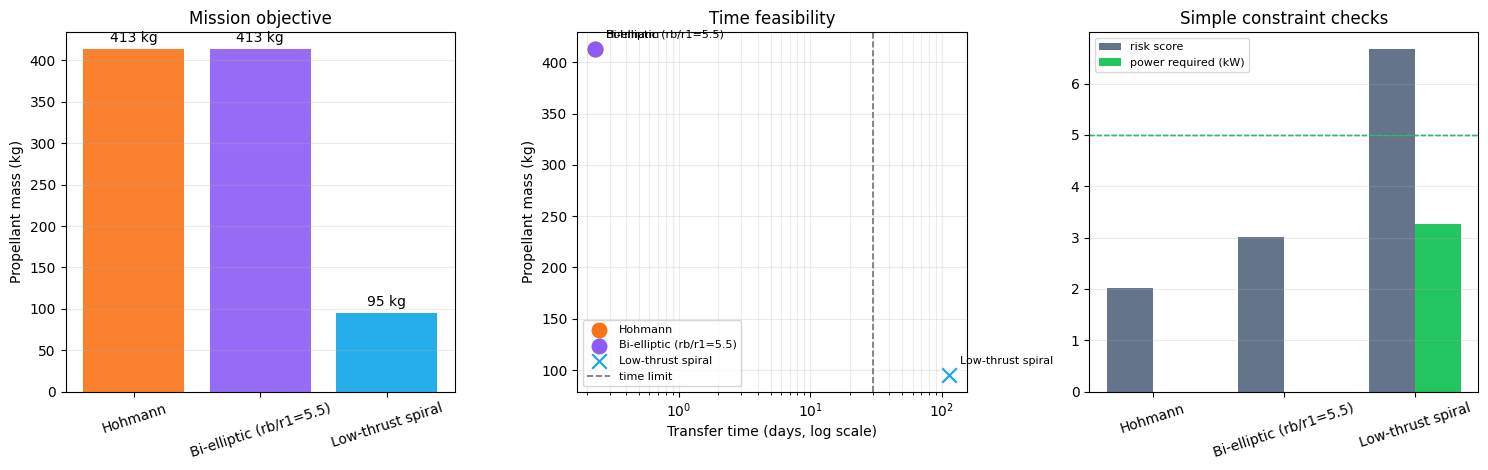

In [45]:
# Layer 4.3: mission result visualization.
def plot_mission_candidates(candidates):
    """Plot propellant mass and constraint tradeoffs for the Mars mini mission."""
    names = [candidate["strategy"] for candidate in candidates]
    propellant = np.array([candidate["propellant_mass_kg"] for candidate in candidates])
    times = np.array([candidate["transfer_time_days"] for candidate in candidates])
    feasible = np.array([candidate["feasible"] for candidate in candidates])
    risk = np.array([candidate["risk_score"] for candidate in candidates])
    power = np.array([candidate["required_power_kw"] for candidate in candidates])
    colors = ["#F97316", "#8B5CF6", "#0EA5E9"]

    fig, axes = plt.subplots(1, 3, figsize=(15, 4.8))
    ax_mass, ax_time, ax_constraints = axes

    bars = ax_mass.bar(names, propellant, color=colors, alpha=0.9)
    ax_mass.bar_label(bars, labels=[f"{value:.0f} kg" for value in propellant], padding=3)
    ax_mass.set(ylabel="Propellant mass (kg)", title="Mission objective")
    ax_mass.tick_params(axis="x", rotation=18)
    ax_mass.grid(axis="y", alpha=0.25)

    for name, time, mass, ok, color in zip(names, times, propellant, feasible, colors):
        marker = "o" if ok else "x"
        ax_time.scatter(time, mass, s=110, color=color, marker=marker, label=name)
        ax_time.annotate(name, (time, mass), xytext=(8, 8), textcoords="offset points", fontsize=8)
    ax_time.axvline(MISSION["time_limit_days"], color="#6B7280", ls="--", lw=1.2,
                    label="time limit")
    ax_time.set_xscale("log")
    ax_time.set(xlabel="Transfer time (days, log scale)",
                ylabel="Propellant mass (kg)",
                title="Time feasibility")
    ax_time.grid(alpha=0.25, which="both")
    ax_time.legend(loc="best", fontsize=8)

    x = np.arange(len(names))
    width = 0.35
    ax_constraints.bar(x - width / 2, risk, width=width, color="#64748B", label="risk score")
    ax_constraints.bar(x + width / 2, power, width=width, color="#22C55E", label="power required (kW)")
    ax_constraints.axhline(MISSION["risk_limit"], color="#64748B", ls="--", lw=1)
    ax_constraints.axhline(MISSION["available_power_kw"], color="#22C55E", ls="--", lw=1)
    ax_constraints.set_xticks(x)
    ax_constraints.set_xticklabels(names, rotation=18)
    ax_constraints.set(title="Simple constraint checks")
    ax_constraints.grid(axis="y", alpha=0.25)
    ax_constraints.legend(loc="best", fontsize=8)

    fig.tight_layout()
    plt.show()


plot_mission_candidates(mission_candidates)


This mini mission shows why the objective matters. If we only compare total `Δv`, low-thrust may not look attractive. But once engine efficiency is included through `Isp`, the electric low-thrust option can use much less propellant mass.

The constraints decide whether that efficient option is useful for the mission. The operations window is represented by the transfer-time limit. The power constraint checks whether the electric-thruster power demand fits within the spacecraft's available power. The operational-risk score is a simple proxy that increases with maneuver count and transfer duration.

In this case the low-thrust spiral saves propellant, but it violates the time and risk constraints. The optimizer therefore chooses the best feasible chemical strategy instead, which both Hohmann and bi-elliptic transfer fit. This is still simplified, but it represents how space mission design connects to optimization, the best option is the lowest-propellant option that also satisfies operational constraints.
